In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.5f}")


In [2]:
PROC = Path(r"D:\yield_curve_forecast\data\processed")

MATURITIES  = np.array([0.25, 1, 2, 5, 10])                 # years
YIELD_COLS  = ["DGS3MO", "DGS1", "DGS2", "DGS5", "DGS10"]

Y_full = pd.read_parquet(PROC / "yield_curve_data.parquet").set_index("observation_date")[YIELD_COLS]
Y_full = Y_full.dropna()

TEST_SIZE = 60
split = len(Y_full) - TEST_SIZE
test_dates = Y_full.index[split:]

actual_curves = Y_full.loc[test_dates]
print(f"Test window: {test_dates[0].date()} -> {test_dates[-1].date()}  ({len(test_dates)} months)")
actual_curves.head()


Test window: 2020-10-01 -> 2025-09-01  (60 months)


,DGS3MO,DGS1,DGS2,DGS5,DGS10
observation_date,,,,,
2020-10-01,0.09000,0.13000,0.14000,0.38000,0.88000
2020-11-01,0.08000,0.11000,0.16000,0.36000,0.84000
2020-12-01,0.09000,0.10000,0.13000,0.36000,0.93000
2021-01-01,0.06000,0.10000,0.11000,0.45000,1.11000
2021-02-01,0.04000,0.08000,0.14000,0.75000,1.44000


In [3]:
p3  = PROC / "predictions.parquet"
p3b = PROC / "dns_predictions.parquet"

p3_raw  = pd.read_parquet(p3)  if p3.exists()  else pd.DataFrame()
p3b_raw = pd.read_parquet(p3b) if p3b.exists() else pd.DataFrame()

DNS_MODELS = {"DNS_AR", "DNS_VAR"}

def load_forecast(model_name, cols=YIELD_COLS):
    src = p3b_raw if model_name in DNS_MODELS else p3_raw
    if src.empty:
        raise FileNotFoundError(
            f"{'dns_predictions.parquet' if model_name in DNS_MODELS else 'predictions.parquet'} "
            f"not found: run the corresponding notebook's save cell first."
        )
    missing = [f"{model_name}__{c}" for c in cols if f"{model_name}__{c}" not in src.columns]
    if missing:
        raise KeyError(f"{model_name} not found for columns {missing}. "
                        f"Available models in this file: "
                        f"{sorted(set(c.split('__')[0] for c in src.columns))}")
    return (src[[f"{model_name}__{c}" for c in cols]]
               .rename(columns=lambda x: x.split("__")[1])
               .reindex(test_dates))

forecast_curves = load_forecast("DNS_VAR")   # or "ARIMA", "VAR_diff", "RandomWalk", "DNS_AR"
forecast_curves.head()


,DGS3MO,DGS1,DGS2,DGS5,DGS10
observation_date,,,,,
2020-10-01,0.17864,0.01062,-0.00012,0.37831,0.86865
2020-11-01,0.16176,0.01273,0.03045,0.48026,1.02975
2020-12-01,0.15400,0.01638,0.03599,0.46496,0.98604
2021-01-01,0.14987,-0.00306,0.01502,0.47621,1.03969
2021-02-01,0.11483,-0.02627,0.01904,0.56449,1.20479


# zero-coupon bond, discrete compounding

In [4]:
def zero_price(y_pct: float, T: float, face: float = 100.0) -> float:
    y = y_pct / 100.0
    return face / (1 + y) ** T


def zero_modified_duration(y_pct: float, T: float) -> float:
    y = y_pct / 100.0
    return T / (1 + y)


def zero_convexity(y_pct: float, T: float) -> float:
    y = y_pct / 100.0
    return T * (T + 1) / (1 + y) ** 2


def duration_convexity_return(y0_pct: float, y1_pct: float, T: float) -> float:
    D = zero_modified_duration(y0_pct, T)
    C = zero_convexity(y0_pct, T)
    dy = (y1_pct - y0_pct) / 100.0
    return -D * dy + 0.5 * C * dy ** 2

def interp_yield(curve_row: pd.Series, target_T: float, maturities: np.ndarray = MATURITIES) -> float:
    order = np.argsort(maturities)
    cs = CubicSpline(maturities[order], curve_row.values[order], extrapolate=True)
    return float(cs(target_T))


### Full-repricing return decomposition: price + carry + roll

In [5]:
def decompose_return(curve_t0: pd.Series, curve_t1: pd.Series, T: float, dt: float = 1/12) -> dict:
    y0 = interp_yield(curve_t0, T)
    P0 = zero_price(y0, T)
    T1 = T - dt

    y1_actual = interp_yield(curve_t1, T1)
    P1_actual = zero_price(y1_actual, T1)
    total_return = P1_actual / P0 - 1

    y1_pricechg = interp_yield(curve_t1, T)
    price_return = zero_price(y1_pricechg, T) / P0 - 1

    y1_roll = interp_yield(curve_t0, T1)
    roll_return = zero_price(y1_roll, T1) / P0 - 1

    carry_return = 0.0
    residual_interaction = total_return - (price_return + roll_return + carry_return)
    dur_conv_check = duration_convexity_return(y0, y1_actual, T)

    return {
        "T": T, "y0": y0, "y1": y1_actual, "P0": P0, "P1": P1_actual,
        "total_return": total_return, "price_return": price_return,
        "roll_return": roll_return, "carry_return": carry_return,
        "residual_interaction": residual_interaction,
        "duration_convexity_check": dur_conv_check,
        "modified_duration": zero_modified_duration(y0, T),
        "convexity": zero_convexity(y0, T),
    }


In [6]:
check = decompose_return(actual_curves.iloc[0], actual_curves.iloc[1], T=0.30, dt=1/12)
for k, v in check.items():
    print(f"{k:28s}: {v:.6f}" if isinstance(v, float) else f"{k:28s}: {v}")


T                           : 0.300000
y0                          : 0.094660
y1                          : 0.078843
P0                          : 99.971619
P1                          : 99.982926
total_return                : 0.000113
price_return                : 0.000039
roll_return                 : 0.000096
carry_return                : 0.000000
residual_interaction        : -0.000022
duration_convexity_check    : 0.000047
modified_duration           : 0.299716
convexity                   : 0.389263


### realized vs. forecast-implied returns

In [7]:
def run_return_engine(actual_curves: pd.DataFrame, forecast_curves: pd.DataFrame,
                       target_maturities=MATURITIES, dt: float = 1/12) -> pd.DataFrame:
    dates = actual_curves.index
    records = []
    for i in range(len(dates) - 1):
        t0, t1 = dates[i], dates[i + 1]
        c0, c1_actual = actual_curves.loc[t0], actual_curves.loc[t1]

        for T in target_maturities:
            rec = decompose_return(c0, c1_actual, T, dt)
            rec.update(date=t1, maturity=T, kind="realized")
            records.append(rec)

            if t1 in forecast_curves.index and not forecast_curves.loc[t1].isna().any():
                rec_f = decompose_return(c0, forecast_curves.loc[t1], T, dt)
                rec_f.update(date=t1, maturity=T, kind="expected")
                records.append(rec_f)

    return pd.DataFrame.from_records(records)

results = run_return_engine(actual_curves, forecast_curves)
results.groupby(["kind", "maturity"])[["total_return", "price_return", "roll_return"]].mean()


total_return  price_return  roll_return
kind     maturity                                         
expected 0.25000        0.00251      -0.00006      0.00260
         1.00000        0.00348       0.00108      0.00252
         2.00000        0.00353       0.00112      0.00231
         5.00000        0.00016      -0.00262      0.00275
         10.00000      -0.00445      -0.00678      0.00193
realized 0.25000        0.00249      -0.00016      0.00260
         1.00000        0.00198      -0.00059      0.00252
         2.00000        0.00122      -0.00113      0.00231
         5.00000        0.00011      -0.00268      0.00275
         10.00000      -0.00309      -0.00505      0.00193

### Directional accuracy

Did the forecast get the **sign** of the return right? This is the metric a desk actually cares about — RMSE on yields doesn't tell you whether the resulting trade would have made money.

          directional_accuracy  n_obs
maturity                             
0.25000                0.72881     59
1.00000                0.84746     59
2.00000                0.61017     59
5.00000                0.61017     59
10.00000               0.61017     59


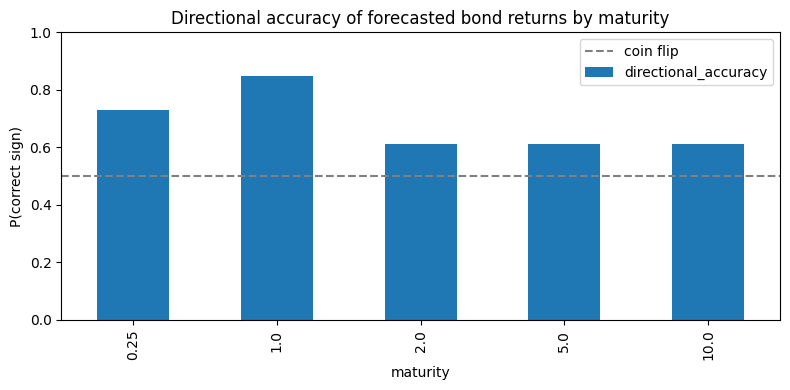

In [8]:
def directional_accuracy(results: pd.DataFrame) -> pd.DataFrame:
    real = results[results.kind == "realized"].set_index(["date", "maturity"])["total_return"]
    exp  = results[results.kind == "expected"].set_index(["date", "maturity"])["total_return"]
    df = pd.concat([real.rename("realized"), exp.rename("expected")], axis=1).dropna()
    df["sign_match"] = np.sign(df["realized"]) == np.sign(df["expected"])
    return (df.groupby(level="maturity")["sign_match"]
              .agg(["mean", "count"])
              .rename(columns={"mean": "directional_accuracy", "count": "n_obs"}))

acc = directional_accuracy(results)
print(acc)

ax = acc["directional_accuracy"].plot(kind="bar", figsize=(8,4), ylim=(0,1))
ax.axhline(0.5, color="grey", ls="--", label="coin flip")
ax.set_title("Directional accuracy of forecasted bond returns by maturity")
ax.set_ylabel("P(correct sign)"); ax.legend()
plt.tight_layout(); plt.show()


### Return decomposition

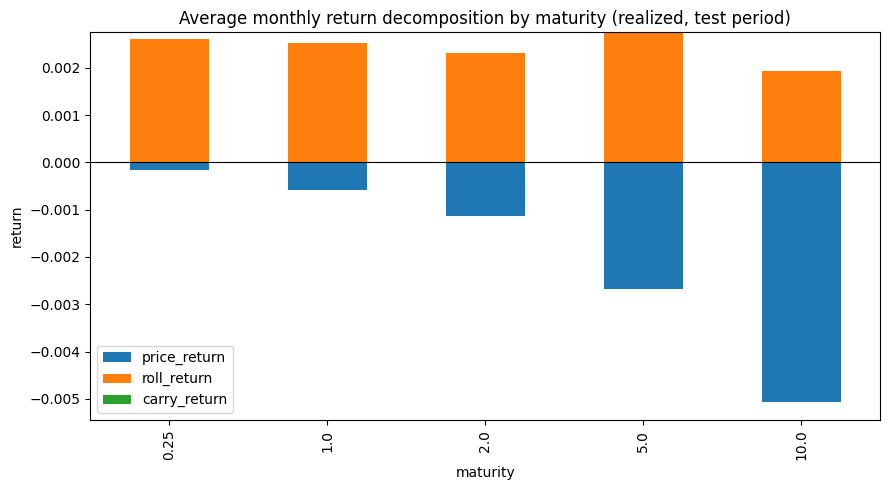

,price_return,roll_return,carry_return
maturity,,,
0.25000,-0.00016,0.00260,0.00000
1.00000,-0.00059,0.00252,0.00000
2.00000,-0.00113,0.00231,0.00000
5.00000,-0.00268,0.00275,0.00000
10.00000,-0.00505,0.00193,0.00000


In [9]:
realized = results[results.kind == "realized"]
comp = realized.groupby("maturity")[["price_return", "roll_return", "carry_return"]].mean()

ax = comp.plot(kind="bar", stacked=True, figsize=(9,5))
ax.set_title("Average monthly return decomposition by maturity (realized, test period)")
ax.set_ylabel("return"); ax.axhline(0, color="black", lw=0.8)
plt.tight_layout(); plt.show()

comp


# Coupon-bond layer


In [10]:
def coupon_bond_price(y_pct: float, coupon_pct: float, T: float,
                       freq: int = 2, face: float = 100.0) -> float:
    y = y_pct / 100.0
    coupon_per_period = (coupon_pct / 100.0) * face / freq
    n_periods = round(T * freq)

    if n_periods <= 0:
        return face + coupon_per_period

    periods = np.arange(1, n_periods + 1)
    times = periods / freq
    discount_factors = (1 + y) ** (-times)

    pv_coupons = coupon_per_period * discount_factors.sum()
    pv_face = face * (1 + y) ** (-T)
    return pv_coupons + pv_face


def par_coupon_rate(y_pct: float, T: float, freq: int = 2, face: float = 100.0) -> float:
    y = y_pct / 100.0
    n_periods = round(T * freq)
    if n_periods <= 0:
        return 0.0

    periods = np.arange(1, n_periods + 1)
    times = periods / freq
    S = ((1 + y) ** (-times)).sum()

    return 100.0 * freq * (1 - (1 + y) ** (-T)) / S


def _resolve_coupon_pct(coupon_pct, curve_t0: pd.Series, T: float,
                         freq: int = 2, face: float = 100.0) -> float:
    if isinstance(coupon_pct, str):
        if coupon_pct != "par":
            raise ValueError(f"Unknown coupon_pct string option: {coupon_pct!r} "
                              f"(only 'par' is supported)")
        y0 = interp_yield(curve_t0, T)
        return par_coupon_rate(y0, T, freq, face)
    if callable(coupon_pct):
        return coupon_pct(curve_t0, T)
    return float(coupon_pct)


def coupon_bond_macaulay_duration(y_pct: float, coupon_pct: float, T: float,
                                   freq: int = 2, face: float = 100.0) -> float:
    y = y_pct / 100.0
    coupon_per_period = (coupon_pct / 100.0) * face / freq
    n_periods = round(T * freq)
    if n_periods <= 0:
        return 0.0

    periods = np.arange(1, n_periods + 1)
    times = periods / freq
    cashflows = np.full(n_periods, coupon_per_period, dtype=float)
    cashflows[-1] += face

    discount_factors = (1 + y) ** (-times)
    pv_cashflows = cashflows * discount_factors
    price = pv_cashflows.sum()
    return float((times * pv_cashflows).sum() / price)


def coupon_bond_modified_duration(y_pct: float, coupon_pct: float, T: float,
                                   freq: int = 2, face: float = 100.0) -> float:
    y = y_pct / 100.0
    D_mac = coupon_bond_macaulay_duration(y_pct, coupon_pct, T, freq, face)
    return D_mac / (1 + y)


def coupon_bond_convexity(y_pct: float, coupon_pct: float, T: float,
                           freq: int = 2, face: float = 100.0) -> float:
    y = y_pct / 100.0
    coupon_per_period = (coupon_pct / 100.0) * face / freq
    n_periods = round(T * freq)
    if n_periods <= 0:
        return 0.0

    periods = np.arange(1, n_periods + 1)
    times = periods / freq
    cashflows = np.full(n_periods, coupon_per_period, dtype=float)
    cashflows[-1] += face

    discount_factors = (1 + y) ** (-times)
    pv_cashflows = cashflows * discount_factors
    price = pv_cashflows.sum()
    weighted = (times * (times + 1) * pv_cashflows).sum()
    return float(weighted / (price * (1 + y) ** 2))

### Coupon return decomposition

In [11]:
def decompose_return_coupon(curve_t0: pd.Series, curve_t1: pd.Series,
                             T: float, coupon_pct, freq: int = 2,
                             dt: float = 1 / 12) -> dict:
    face = 100.0
    coupon_pct_resolved = _resolve_coupon_pct(coupon_pct, curve_t0, T, freq, face)

    y0 = interp_yield(curve_t0, T)
    P0 = coupon_bond_price(y0, coupon_pct_resolved, T, freq, face)

    T1 = T - dt
    coupon_income = (coupon_pct_resolved / 100.0) * face * dt

    y1_actual = interp_yield(curve_t1, T1)
    P1_actual = coupon_bond_price(y1_actual, coupon_pct_resolved, T1, freq, face)
    total_return = (P1_actual + coupon_income) / P0 - 1

    y1_pricechg = interp_yield(curve_t1, T)
    price_return = coupon_bond_price(y1_pricechg, coupon_pct_resolved, T, freq, face) / P0 - 1

    y1_roll = interp_yield(curve_t0, T1)
    roll_return = coupon_bond_price(y1_roll, coupon_pct_resolved, T1, freq, face) / P0 - 1

    carry_return = coupon_income / P0
    residual_interaction = total_return - (price_return + roll_return + carry_return)

    return {
        "T": T, "coupon_pct": coupon_pct_resolved,
        "y0": y0, "y1": y1_actual, "P0": P0, "P1": P1_actual,
        "total_return": total_return,
        "price_return": price_return,
        "roll_return": roll_return,
        "carry_return": carry_return,
        "residual_interaction": residual_interaction,
        "modified_duration": coupon_bond_modified_duration(y0, coupon_pct_resolved, T, freq, face),
        "convexity": coupon_bond_convexity(y0, coupon_pct_resolved, T, freq, face),
    }

### validation

In [12]:
def validate_coupon_engine(curve_t0: pd.Series, curve_t1: pd.Series,
                            T: float = 5.0, tol: float = 1e-8):
    y0 = interp_yield(curve_t0, T)

    p_zero = zero_price(y0, T)
    p_coupon_zero = coupon_bond_price(y0, coupon_pct=0.0, T=T)
    price_ok = abs(p_zero - p_coupon_zero) < tol

    out_zero = decompose_return(curve_t0, curve_t1, T)
    out_coupon = decompose_return_coupon(curve_t0, curve_t1, T, coupon_pct=0.0)

    mismatches = {
        k: (out_zero[k], out_coupon[k])
        for k in ("total_return", "price_return", "roll_return")
        if abs(out_zero[k] - out_coupon[k]) > tol
    }

    print(f"zero_price vs coupon_bond_price(coupon=0): "
          f"{'MATCH' if price_ok else 'MISMATCH'}  ({p_zero:.6f} vs {p_coupon_zero:.6f})")
    print(f"decompose_return vs decompose_return_coupon(coupon=0): "
          f"{'MATCH' if not mismatches else 'MISMATCH -> ' + str(mismatches)}")

    # Bonus check: par_coupon_rate should make P0 == face exactly.
    par_rate = par_coupon_rate(y0, T)
    p_par = coupon_bond_price(y0, par_rate, T)
    par_ok = abs(p_par - 100.0) < tol
    print(f"par_coupon_rate check: coupon={par_rate:.4f}%  ->  P0={p_par:.6f}  "
          f"{'MATCH (par)' if par_ok else 'MISMATCH'}")

    return price_ok and not mismatches and par_ok

validate_coupon_engine(actual_curves.iloc[0], actual_curves.iloc[1])

zero_price vs coupon_bond_price(coupon=0): MATCH  (98.121469 vs 98.121469)
decompose_return vs decompose_return_coupon(coupon=0): MATCH
par_coupon_rate check: coupon=0.3796%  ->  P0=100.000000  MATCH (par)


np.True_

### example

In [13]:
def run_return_engine_coupon(actual_curves: pd.DataFrame,
                              forecast_curves: pd.DataFrame,
                              coupon_pct,
                              target_maturities=MATURITIES,
                              freq: int = 2,
                              dt: float = 1 / 12) -> pd.DataFrame:
    dates = actual_curves.index
    records = []

    for i in range(len(dates) - 1):
        t0, t1 = dates[i], dates[i + 1]
        c0, c1_actual = actual_curves.loc[t0], actual_curves.loc[t1]

        for T in target_maturities:
            rec = decompose_return_coupon(c0, c1_actual, T, coupon_pct, freq, dt)
            rec.update(date=t1, maturity=T, kind="realized")
            records.append(rec)

            if t1 in forecast_curves.index and not forecast_curves.loc[t1].isna().any():
                rec_f = decompose_return_coupon(c0, forecast_curves.loc[t1], T, coupon_pct, freq, dt)
                rec_f.update(date=t1, maturity=T, kind="expected")
                records.append(rec_f)

    return pd.DataFrame.from_records(records)


coupon_results = run_return_engine_coupon(actual_curves, forecast_curves, coupon_pct=4.0)
coupon_results.groupby(["kind", "maturity"])[["total_return", "price_return", "roll_return", "carry_return"]].mean()

total_return  price_return  roll_return  carry_return
kind     maturity                                                       
expected 0.25000        0.00327       0.00000      0.00000       0.00327
         1.00000        0.00668       0.00107      0.00242       0.00331
         2.00000        0.00659       0.00109      0.00213       0.00327
         5.00000        0.00310      -0.00241      0.00228       0.00319
         10.00000      -0.00106      -0.00571      0.00120       0.00313
realized 0.25000        0.00327       0.00000      0.00000       0.00327
         1.00000        0.00519      -0.00058      0.00242       0.00331
         2.00000        0.00434      -0.00110      0.00213       0.00327
         5.00000        0.00303      -0.00247      0.00228       0.00319
         10.00000       0.00002      -0.00433      0.00120       0.00313

          directional_accuracy  n_obs
maturity                             
0.25000                1.00000     59
1.00000                0.96610     59
2.00000                0.77966     59
5.00000                0.61017     59
10.00000               0.69492     59


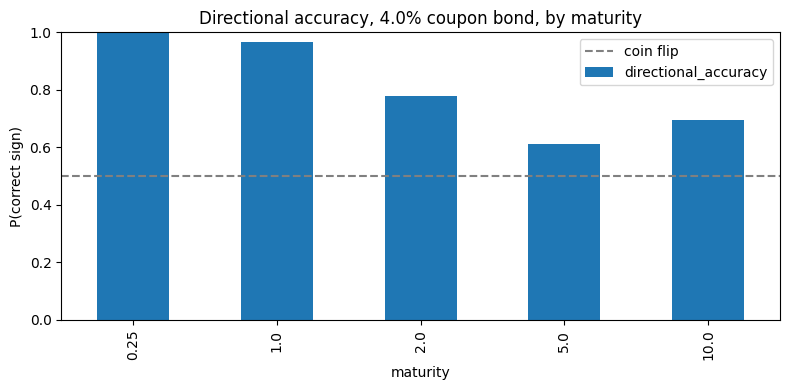

In [14]:
coupon_acc = directional_accuracy(coupon_results)
print(coupon_acc)

ax = coupon_acc["directional_accuracy"].plot(kind="bar", figsize=(8, 4), ylim=(0, 1))
ax.axhline(0.5, color="grey", ls="--", label="coin flip")
ax.set_title(f"Directional accuracy, {4.0:.1f}% coupon bond, by maturity")
ax.set_ylabel("P(correct sign)"); ax.legend()
plt.tight_layout(); plt.show()

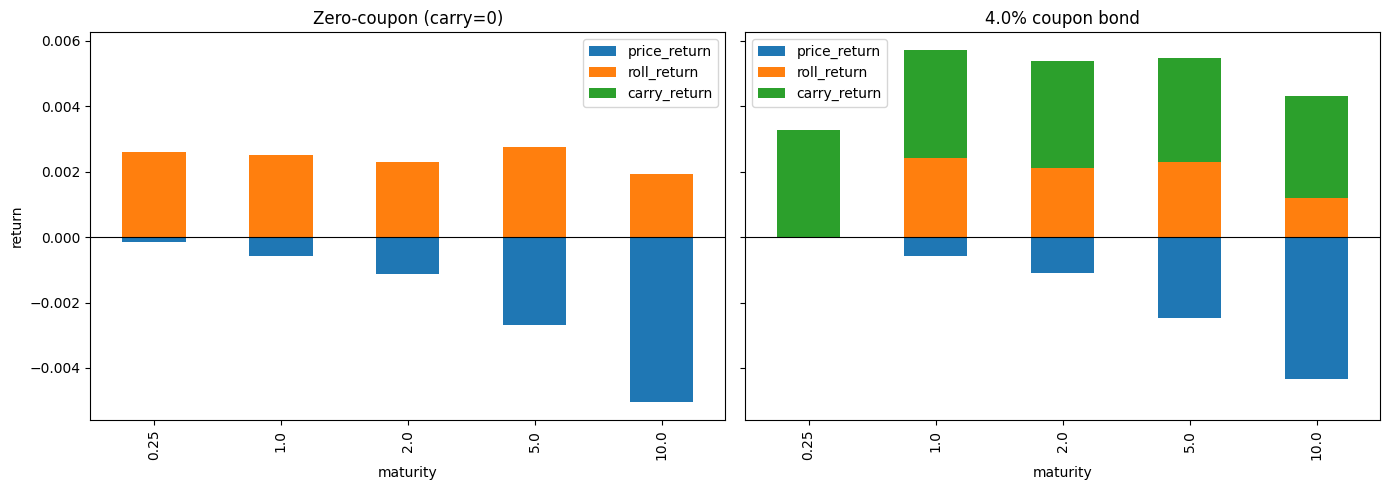

In [15]:
zero_realized = results[results.kind == "realized"].groupby("maturity")[["price_return", "roll_return", "carry_return"]].mean()
coupon_realized = coupon_results[coupon_results.kind == "realized"].groupby("maturity")[["price_return", "roll_return", "carry_return"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
zero_realized.plot(kind="bar", stacked=True, ax=axes[0], title="Zero-coupon (carry=0)")
coupon_realized.plot(kind="bar", stacked=True, ax=axes[1], title=f"{4.0:.1f}% coupon bond")
for ax in axes:
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("return")
plt.tight_layout(); plt.show()